<a href="https://colab.research.google.com/github/gauravpatra03-sketch/Deep-Learning/blob/main/GenAI_Week1_Ex1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import libraries

In [11]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Load dataset

In [12]:
(x_train, y_train), (x_test, y_test) =datasets.cifar10.load_data()

#Normalize pixel values to [0,1]
x_train=x_train/255.0
x_test=x_test/255.0

class_names=[
    'airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck'
]

print("Training data shape: ",x_train.shape)
print("Testing data shape: ",x_test.shape)

Training data shape:  (50000, 32, 32, 3)
Testing data shape:  (10000, 32, 32, 3)


Display sample images

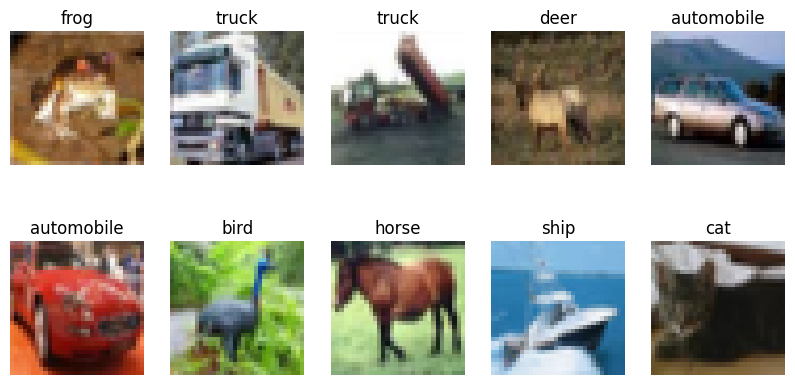

In [14]:
plt.figure(figsize=(10,5))

for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_train[i])
  plt.title(class_names[y_train[i][0]])
  plt.axis('off')

plt.show()

Build CNN model

In [17]:
model=models.Sequential()

#First Convolution Block
model.add(layers.Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    input_shape=(32,32,3)
))
model.add(layers.MaxPooling2D((2,2)))

#Second Convolution Block
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

#Third Convolution Block
model.add(layers.Conv2D(128,(3,3),activation='relu'))

#Flatten layer
model.add(layers.Flatten())

#Fully cConnected Layers
model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dropout(0.5))

#Output Layer
model.add(layers.Dense(10, activation='softmax'))

Compile model

In [18]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train model

In [19]:
history=model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 97ms/step - accuracy: 0.3682 - loss: 1.7199 - val_accuracy: 0.4803 - val_loss: 1.4218
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.5109 - loss: 1.3678 - val_accuracy: 0.5559 - val_loss: 1.2381
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.5713 - loss: 1.2138 - val_accuracy: 0.6003 - val_loss: 1.1245
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 96ms/step - accuracy: 0.6152 - loss: 1.0987 - val_accuracy: 0.6431 - val_loss: 0.9971
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 97ms/step - accuracy: 0.6470 - loss: 1.0119 - val_accuracy: 0.6750 - val_loss: 0.9207
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.6714 - loss: 0.9399 - val_accuracy: 0.6940 - val_loss: 0.8793
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.6978 - loss: 0.8734 - val_accuracy: 0.6978 - val_loss: 0.8640
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.7142 - loss: 0.8207 - 

Plot accuracy and loss

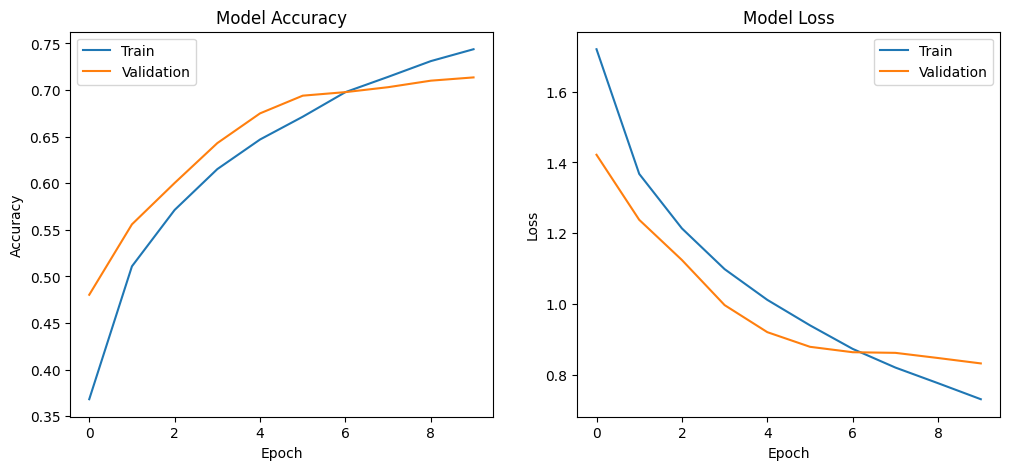

In [20]:
plt.figure(figsize=(12,5))

#Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Train')
plt.plot(history.history['val_accuracy'],label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

#Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='Train')
plt.plot(history.history['val_loss'],label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Evaluate on test data

In [21]:
test_loss,test_acc=model.evaluate(x_test,y_test)

print("\nTest Accuracy: ",test_acc)
print("Test Loss: ",test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7137 - loss: 0.8365

Test Accuracy:  0.713699996471405
Test Loss:  0.83645099401474


Predictions

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


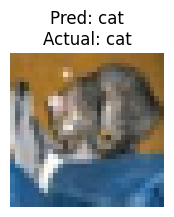

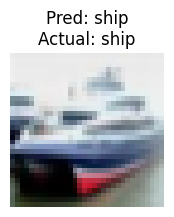

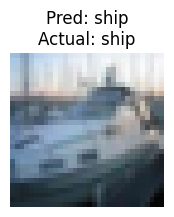

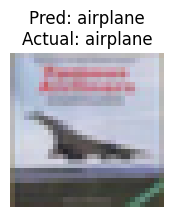

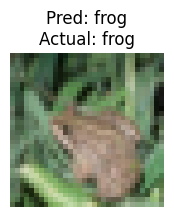

In [22]:
predictions=model.predict(x_test)

for i in range(5):
  predicted_label=np.argmax(predictions[i])
  actual_label=y_test[i][0]

  plt.figure(figsize=(2,2))
  plt.imshow(x_test[i])
  plt.title(
      f"Pred: {class_names[predicted_label]}\n"
      f"Actual: {class_names[actual_label]}"
  )
  plt.axis('off')
  plt.show()

Confusion matrix

<Figure size 1000x800 with 0 Axes>

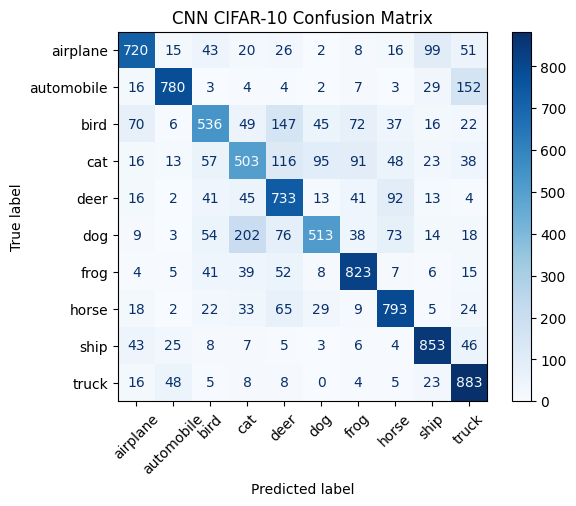

In [23]:
#Predicted labels
y_pred=np.argmax(predictions,axis=1)

#True labels
y_true=y_test.flatten()

#Compute confusion matrix
cm=confusion_matrix(y_true,y_pred)

#Display Confusion matrix
plt.figure(figsize=(10,8))

disp=ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap='Blues',xticks_rotation=45)

plt.title("CNN CIFAR-10 Confusion Matrix")
plt.show()